In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [2]:
df = pd.read_csv('heart.csv')
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
963,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
358,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
905,64,1,0,120,246,0,0,96,1,2.2,0,1,2,0
282,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


In [3]:
print(f"{df.shape[0]} rows and {df.shape[1]} columns in the dataset.")
print(f"Columns in the dataset: {df.columns.tolist()}")
print(f"Missing values in the dataset:\n{df.isnull().sum()}")
print(f"Data types of the columns:\n{df.dtypes}")

1025 rows and 14 columns in the dataset.
Columns in the dataset: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Missing values in the dataset:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Data types of the columns:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Data is not Dirty and No need for cleaning or dropping Columns or Rows

In [4]:
print(f"Info of the dataset:\n{df.info()}")
print(f"Statistical summary of the dataset:\n{df.describe()}")

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
Info of the dataset:
None
Statistical summary of the dataset:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146 

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
Dtree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

Dtree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [8]:
y_pred = Dtree.predict(X_test)

print(f"Score on Testing Data is {accuracy_score(y_test, y_pred)}")
print(f"Score on training Data is {Dtree.score(X_train, y_train)}")

Score on Testing Data is 0.824390243902439
Score on training Data is 0.8439024390243902


In [9]:
for i in range(1, 21):
    trees = DecisionTreeClassifier(criterion='gini', max_depth=i, random_state=42)
    trees.fit(X_train, y_train)
    y_pred = trees.predict(X_test)
    print(f"Max Depth: {i}, Score on Test data: {accuracy_score(y_test, y_pred)}, Score on training data: {accuracy_score(y_train, trees.predict(X_train))}")

Max Depth: 1, Score on Test data: 0.751219512195122, Score on training data: 0.7621951219512195
Max Depth: 2, Score on Test data: 0.6926829268292682, Score on training data: 0.7658536585365854
Max Depth: 3, Score on Test data: 0.824390243902439, Score on training data: 0.8439024390243902
Max Depth: 4, Score on Test data: 0.824390243902439, Score on training data: 0.8731707317073171
Max Depth: 5, Score on Test data: 0.8731707317073171, Score on training data: 0.9414634146341463
Max Depth: 6, Score on Test data: 0.9365853658536586, Score on training data: 0.9682926829268292
Max Depth: 7, Score on Test data: 0.9560975609756097, Score on training data: 0.9841463414634146
Max Depth: 8, Score on Test data: 0.975609756097561, Score on training data: 0.9939024390243902
Max Depth: 9, Score on Test data: 0.9804878048780488, Score on training data: 0.9963414634146341
Max Depth: 10, Score on Test data: 0.9804878048780488, Score on training data: 0.9963414634146341
Max Depth: 11, Score on Test data

3 Depth Given the best result after depth 13 its all over fitting

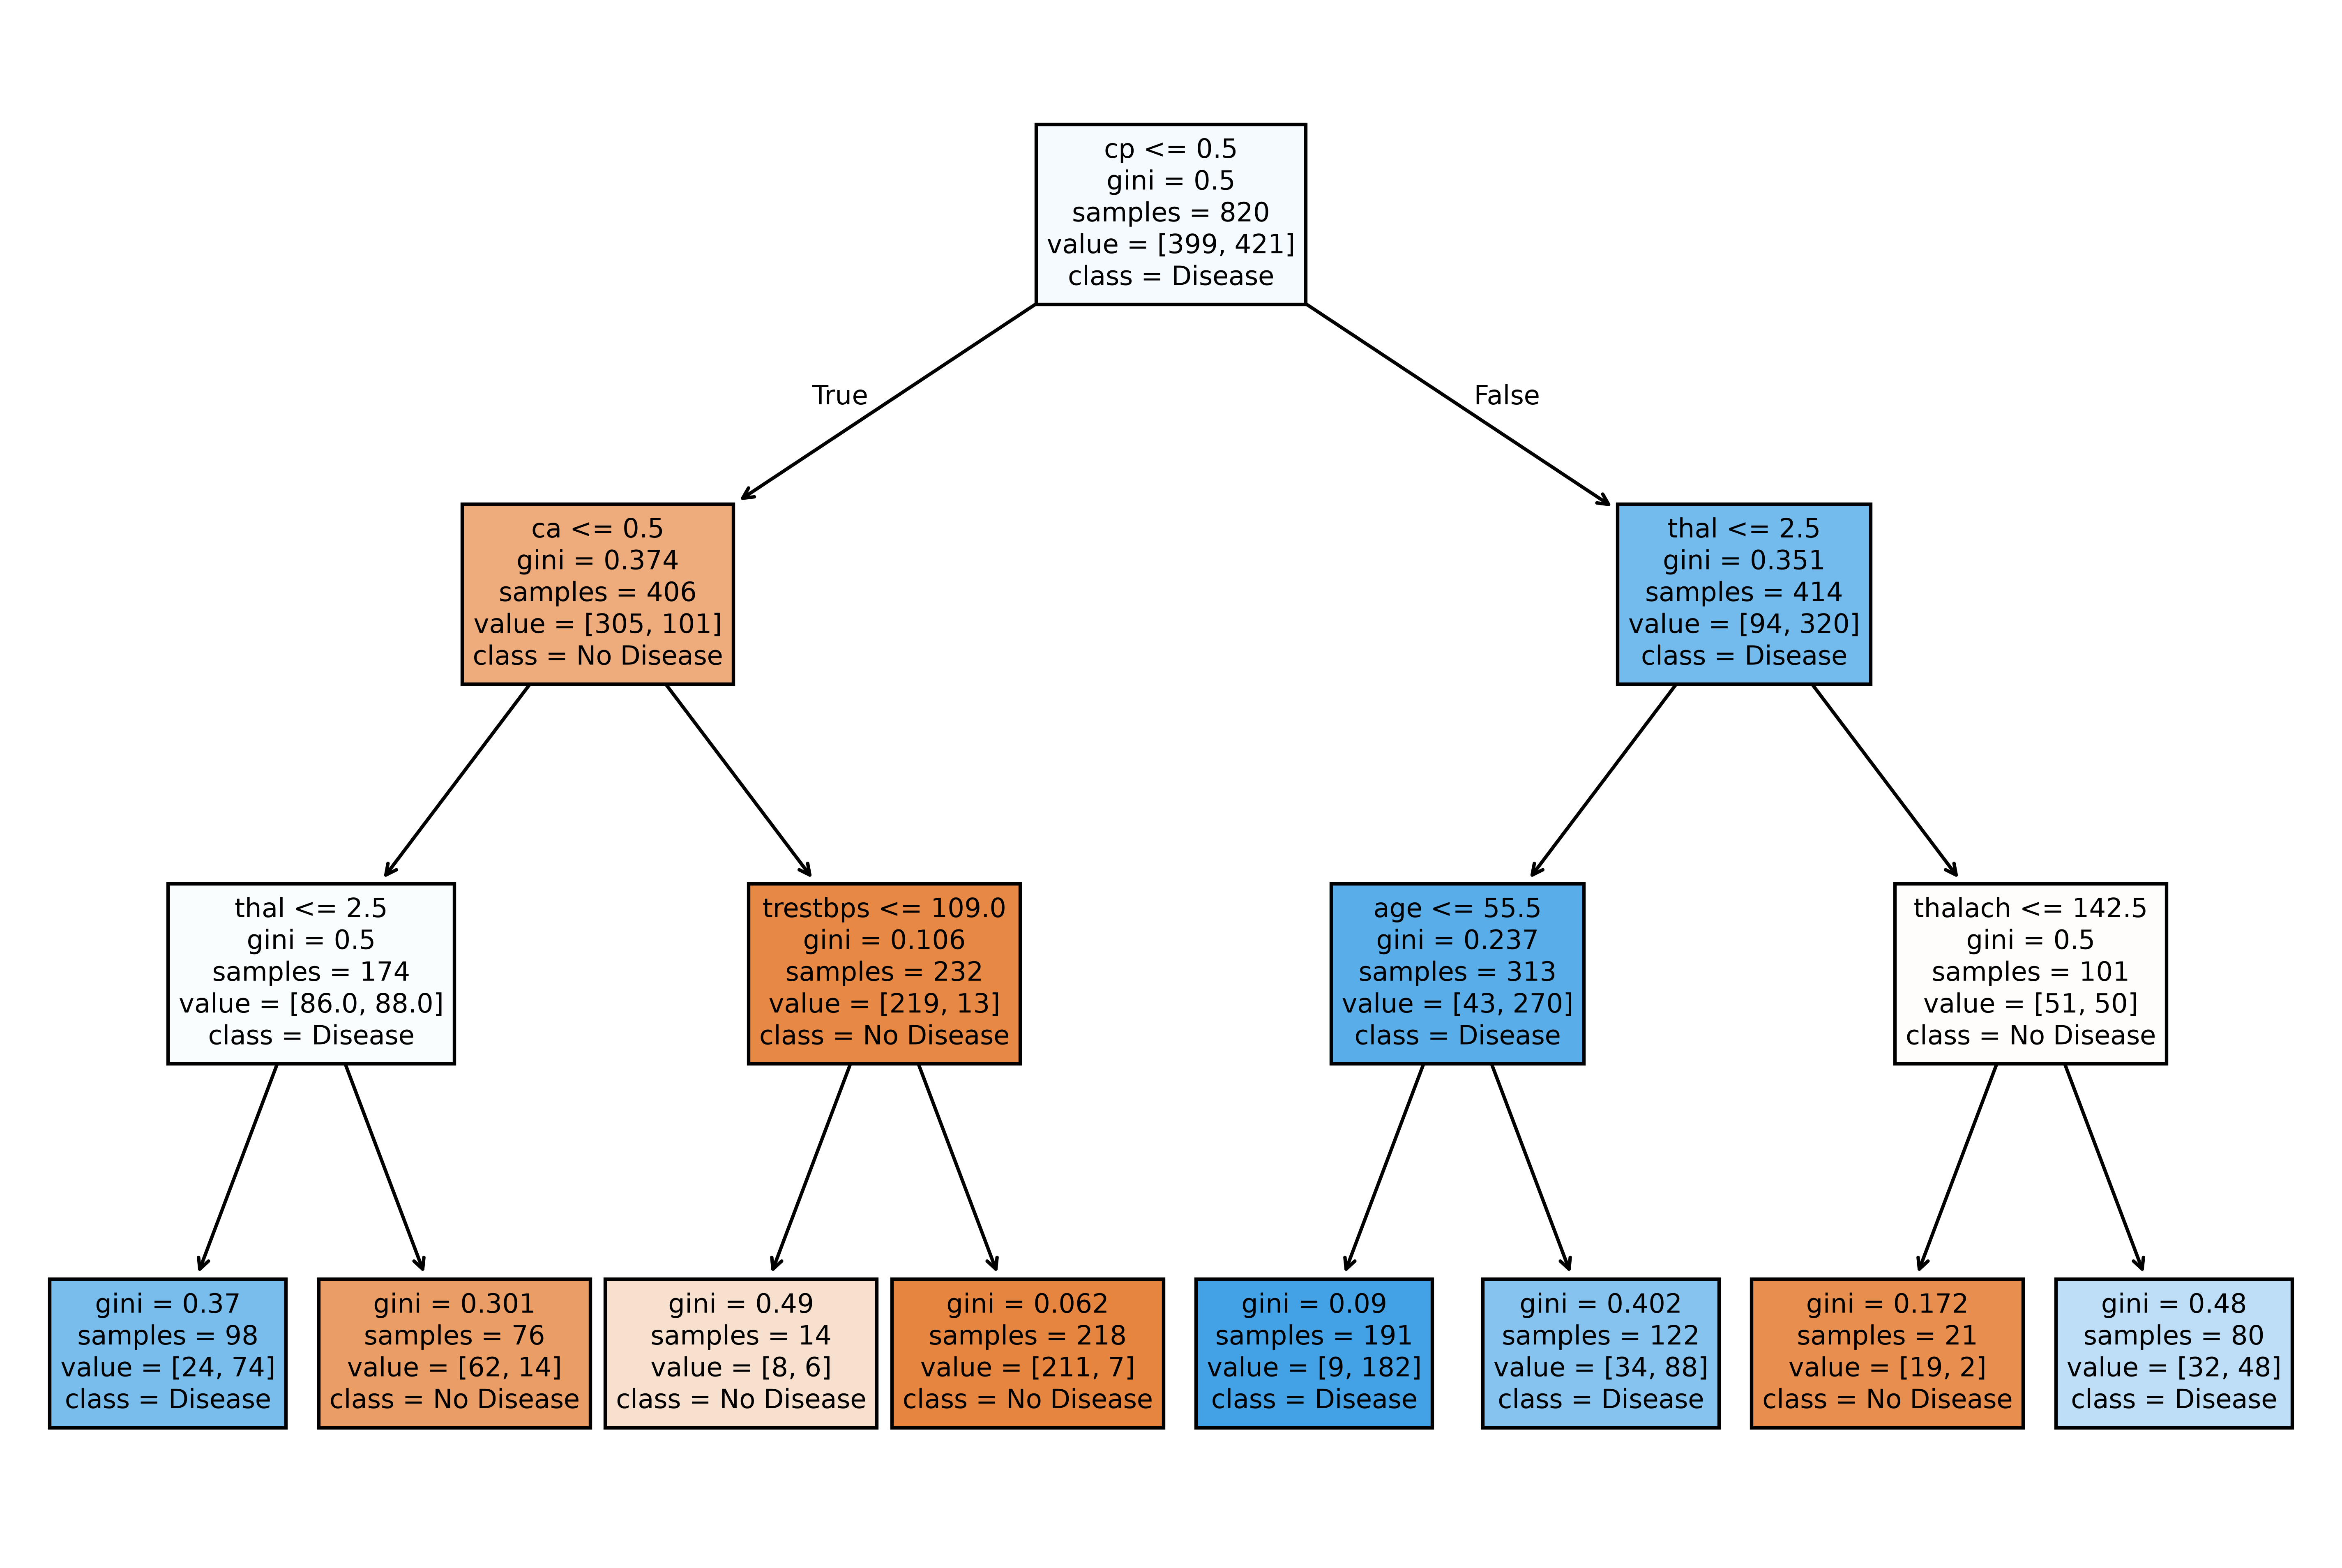

In [10]:
from sklearn import tree
plt.figure(figsize=(12,8), dpi= 600)
plt.title("Decision Tree for Heart Disease Prediction")
tree.plot_tree(Dtree, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], filled=True)

plt.show()

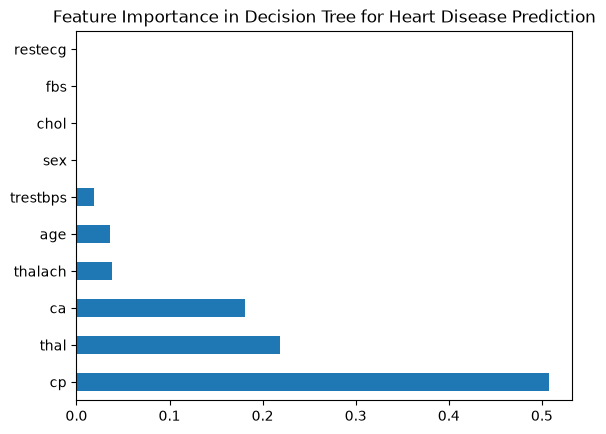

In [11]:
feat_importances = pd.Series(Dtree.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Feature Importance in Decision Tree for Heart Disease Prediction")
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Confusion Matrix:
[[100   0]
 [  3 102]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Classification Report — Class by Class

**Class 1 (Disease):** TP=?, FP=?, FN=? | **Class 0 (No):** flip roles → TP=?, FP=?, FN=?

| Metric | Formula | Class 1 | Class 0 |
|---|---|---|---|
| Precision | TP/(TP+FP) | ?/? = **?** | ?/? = **?** |
| Recall | TP/(TP+FN) | ?/? = **?** | ?/? = **?** |
| F1 | 2PR/(P+R) | **?** | **?** |
| Support | actual count | ? | ? |

- **Precision** → when model says this class, how often right?
- **Recall** → of all real cases, how many caught?
- **F1** → balance of both.
- **macro avg** = plain mean · **weighted avg** = weighted by support

**Takeaway:** fill the TP/FP/FN values from the Confusion Matrix cell above.
For medical data, recall on class 1 matters most → fix with SMOTE, `max_depth` tuning, or threshold adjustment.

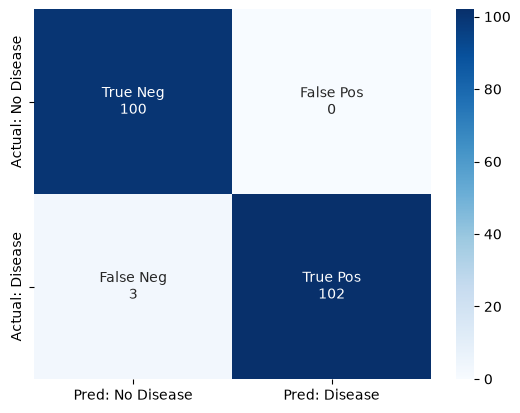

In [13]:
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = [f"{v}" for v in cm.flatten()]
labels = np.asarray([f"{n}\n{c}" for n, c in zip(group_names, group_counts)]).reshape(2, 2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Pred: No Disease', 'Pred: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'])
plt.show()

In [14]:
import pickle
with open('Dtree_heart_model.pkl', 'wb') as f:
    pickle.dump(Dtree, f)